# **Procesamiento de datos mediante Apache Spark**

### **Autores**

Eduardo Alarcón Navarro - 100472175@alumnos.uc3m.es

Ángela Ochoa Lavieja - 100562058@alumnos.uc3m.es

Lucía Velasco González - 100383335@alumnos.uc3m.es

Manuel Gómez-Plana Rodríguez - 100472310@alumnos.uc3m.es

# **Índice de la práctica**

1. [**Introducción**](#introduccion): se introduce la práctica.
2. [**Problemas**](#problemas): se introducen los posibles problemas planteados para realizar el estudio y el problema escogido para su análisis.
3. [**Resolución**](#resolucion): se resuelven los problemas no elegidos mediante el uso de dataframes y el problema seleccionado mediante tres técnicas distintas: consultas `SQL`, concatenación de operaciones sobre los `dataframes de Pandas` y uso de `RDDs`.
   - 3.1. [**Problema 1**](#problema-1): Cálculo de velocidad media.
   - 3.2. [**Problema 2**](#problema-2): Barrios y zonas con más propinas.
   - 3.3. [**Problema 3**](#problema-3): Tipo de pago por rango de precio.
     
5. [**Análisis**](#analisis): se analizan los resultados obtenidos de los tres problemas para determinar aspectos como la solución más rápida, el speedup obtenido mediante cada técnica o la escalabilidad de las soluciones.
6. [**Conclusiones**](#conclusiones): se concluye el trabajo con unos pensamientos finales.

# **1. Introducción**
<a id="introduccion"></a>

Este documento guarda la información relacionada con la elaboración de la práctica 1 de la asignatura Computación de Altas Prestaciones del Máster Universitario en Ciencia y Tecnología Informática.

# **2. Problemas**
<a id="problemas"></a>

Esta sección introduce los problemas planteados, así como el problema elegido. Se ha decidido plantear 3 problemas distintos:

1. Cálculo de la velocidad media de los trayectos según la hora.
2. Análisis geográfico de los barrios y zonas donde los clientes dan más propinas.
3. Análisis del tipo de pago por rango de precios de los trayectos.

Por razones de complejidad, se ha escogido el primer problema planteado, "Cálculo de la velocidad media según la hora", si bien se ha implementado una resolución empleando los dataframes de `Spark` para el resto de problemas. Estas resoluciones se encuentran en los siguientes apartados.

# **3. Resolución**
<a id="resolucion"></a>

Este apartado contiene el código relacionado con la carga del dataset y una descripción de la metodología seguida para resolver los problemas planteados. Primero, se planteará la resolución mediante los tres métodos mencionados del problema escogido, tras lo que se mostrará un planteamiento con código de los problemas no escogidos.

Para poder trabajar con los datos, primero hay que crear una sesión de `Spark`. Esto se realiza mediante el siguiente código:

In [1]:
if 1:
    for year in range(2024, 2025+1):
        for i in range(1,12+1):
            index = i if i >= 10 else "0"+str(i)
            url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{index}.parquet"
            destination = f"content/yellow_tripdata_{year}-{index}.parquet"
            !wget {url} -O {destination}

--2025-10-26 12:53:20--  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet
Resolving d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)... 3.160.226.85, 3.160.226.228, 3.160.226.161, ...
Connecting to d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)|3.160.226.85|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 49961641 (48M) [binary/octet-stream]
Saving to: ‘content/yellow_tripdata_2024-01.parquet’

content/yellow_trip 100%[===================>]  47.65M  33.4MB/s    in 1.4s    

2025-10-26 12:53:21 (33.4 MB/s) - ‘content/yellow_tripdata_2024-01.parquet’ saved [49961641/49961641]

--2025-10-26 12:53:22--  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-02.parquet
Resolving d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)... 3.160.226.85, 3.160.226.111, 3.160.226.228, ...
Connecting to d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)|3.160.226.85|:443... connected

In [2]:
# Importado de Spark y sus funciones adicionales
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf
from pyspark.sql.functions import *

# Importado de librerías auxiliares
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import pprint
import json
import gc

In [3]:
# Creación de la sesión de spark
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('TaxiAnalysis') \
    .config('spark.driver.memory', '40g') \
    .config('spark.executor.memory', '40g') \
    .config('spark.driver.maxResultSize', '40g') \
    .getOrCreate()


sc = spark.sparkContext
sc

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/10/26 12:54:04 WARN Utils: Your hostname, edu-ubuntu, resolves to a loopback address: 127.0.1.1; using 192.168.1.106 instead (on interface wlp6s0)
25/10/26 12:54:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/26 12:54:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


<SparkContext master=local[*] appName=TaxiAnalysis>

In [4]:
!pip install psutil
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

zsh:1: command not found: pip
Your runtime has 32.5 gigabytes of available RAM



Tras esto, es necesario cargar los datos que se van a usar en los análisis. Antes de esto, se ha decidio cargar un `csv` que muestra información contextual adicional para cada localización basándose en su ID. Esto permite mostrar una información más completa y legible para las consultas que usen las localizaciones, y esta carga se realiza con el siguiente código:

In [5]:
zone_map = spark.read.format("csv"). \
    option("inferSchema", "true"). \
    option("header", "true"). \
    option("mode", "DROPMALFORMED"). \
    load("taxi_zone_lookup.csv")
zone_map.show()
# zone_map: dict[int, list[str]] = zone_map.toPandas().set_index('LocationID').T.to_dict('list')

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
|         6|Staten Island|Arrochar/Fort Wad...|   Boro Zone|
|         7|       Queens|             Astoria|   Boro Zone|
|         8|       Queens|        Astoria Park|   Boro Zone|
|         9|       Queens|          Auburndale|   Boro Zone|
|        10|       Queens|        Baisley Park|   Boro Zone|
|        11|     Brooklyn|          Bath Beach|   Boro Zone|
|        12|    Manhattan|        Battery Park| Yellow Zone|
|        13|    Manhattan|   Battery Park City| Yellow Zone|
|        14|     Brookly

Por último, se carga el dataset obtenido con la información de los trayectos de los taxis `yellow_cab` de la ciudad de Nueva York. Esto se hace con un comando de `Spark`, que carga el fichero `.parquet`, especificando parámetros como el formato de la fecha o la inclusión de los headers. Esta carga se realiza con el siguiente código:

In [6]:
df = spark.read.format("parquet") \
    .option("inferSchema", "true")  \
    .option("timestampFormat","yyyy-MM-dd HH:mm:ss") \
    .option("header", "true") \
    .option("mode", "DROPMALFORMED") \
    .option("pathGlobFilter", "*.parquet") \
    .load("content/")


df.printSchema()
df.show(5)

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------

In [7]:
from pyspark.sql.types import *

# Load parquet files without enforcing schema, allowing Spark to infer
# This prevents schema merge conflicts from different parquet file versions
df = spark.read \
    .option("mergeSchema", "false") \
    .option("mode", "PERMISSIVE") \
    .parquet("content/yellow_tripdata_*.parquet")

# Cast all columns to ensure consistent types across all data
# This handles inconsistencies like airport_fee being INT vs DOUBLE in different files but not 'passenger_count'
df = df.select(
    col("VendorID").cast(LongType()),
    col("tpep_pickup_datetime").cast(TimestampType()),
    col("tpep_dropoff_datetime").cast(TimestampType()),
    col("passenger_count").cast(LongType()), 
    col("trip_distance").cast(DoubleType()),
    col("RatecodeID").cast(DoubleType()),
    col("store_and_fwd_flag").cast(StringType()),
    col("PULocationID").cast(LongType()),
    col("DOLocationID").cast(LongType()),
    col("payment_type").cast(LongType()),
    col("fare_amount").cast(DoubleType()),
    col("extra").cast(DoubleType()),
    col("mta_tax").cast(DoubleType()),
    col("tip_amount").cast(DoubleType()),
    col("tolls_amount").cast(DoubleType()),
    col("improvement_surcharge").cast(DoubleType()),
    col("total_amount").cast(DoubleType()),
    col("congestion_surcharge").cast(DoubleType()),
    col("airport_fee").cast(DoubleType()) 
)

df.printSchema()
df.show(5)

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)



25/10/26 12:54:10 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: content/yellow_tripdata_*.parquet.
java.io.FileNotFoundException: File content/yellow_tripdata_*.parquet does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:917)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1238)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:907)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.FileStreamSink$.hasMetadata(FileStreamSink.scala:56)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:381)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:143)
	at org.apache.spark.sql.cat

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       1| 2025-05-01 00:07:06|  2025-05-01 00:24:15|              1|          3.7|       1.0|                 N|         140|         202|           1|       18.4| 4.25|    0.5|      4.8

## **3.1. Problema 1: Cálculo de velocidad media**
<a id="problema-1"></a>

Este problema tiene como objetivo mostrar la velocidad media de los trayectos agrupando los viajes por horas. Para poder resolver este problema, se ha planteado agrupar los trayectos por la hora de inicio del viaje. Antes de resolver este problema, se ha limpiado el dataset eliminando aquellos viajes cuya distancia fuese de 0 millas y aquellos trayectos cuyo `datetime` de inicio fuese igual al del final. Esto se ha realizado mediante el siguiente código: 

In [8]:
# Eliminado de viajes sin distancia
df = df.filter(df.trip_distance != 0)

# Eliminado los viajes que tengan 0 pasajeros
df = df.filter(df.passenger_count != 0)

# Convert passenger_count a int
df = df.filter(df.passenger_count.isNotNull() & (df.passenger_count != 0))
df = df.withColumn("passenger_count", col("passenger_count").cast("long"))

# Eliminado de viajes instantáneos
df = df.filter(df.tpep_pickup_datetime != df.tpep_dropoff_datetime)



# TODO: hacer más filtros

### **3.1.1. Resolución mediante SQL**

Primero, se resuelve este problema mediante `SQL`. Para ello, se ha diseñado una query que:

1. Selecciona de la hora de inicio de los viajes empleando la función `HOUR` para obtener la hora de un `datetime`.
2. Escoge la media de la velocidad de cada viaje. Para ello:
    - Selecciona la distancia viajada que se encuentra en la columna `trip_distance`.
    - Divide la distancia entre la diferencia (en segundos) del `datetime` de final del viaje y del `datetime` del inicio del viaje para calcular la velocidad en *mi/s*.
    - Calcula $vel * 1.6093 * 3600$ para mostrar la velocidad en *km/h*.
    - Emplea la función `AVG` para calcular la media de las velocidades agrupadas (paso 3).
3. Agrupa por la hora de cada viaje para que las velocidades medias se calculen según su hora de inicio.
4. Muestra el resultado obtenido ordenando por la hora de inicio de manera ascendente.ç

Este proceso se muestra en el siguiente código:

In [9]:
start_sql = time.time()
TABLE_NAME = 'taxi_routes'

# TODO: Eliminar este SQL
SQL = f"""SELECT HOUR(tpep_pickup_datetime) AS hour,
            ROUND(AVG(trip_distance / DATE_DIFF(SECOND,tpep_pickup_datetime,tpep_dropoff_datetime))*1.6*3600, 2) as vel_media_km_h 
            FROM {TABLE_NAME} 
            GROUP BY hour 
            SORT BY hour """

# Query a usar
SQL = f"""SELECT HOUR(tpep_pickup_datetime) AS hour,
            AVG(trip_distance / DATE_DIFF(SECOND,tpep_pickup_datetime,tpep_dropoff_datetime))*1.6093*3600 as vel_media_km_h 
            FROM {TABLE_NAME} 
            GROUP BY hour 
            SORT BY hour """

# Creación de una vista sobre la tabla y ejecución de la query
df.createOrReplaceTempView(TABLE_NAME)
sql_result = spark.sql(SQL)

# Mostrado de los resultados
sql_result.show(24)
print(sql_result)
end_sql = time.time()
print(f'Time taken: {end_sql-start_sql:.2f} seconds')

+----+------------------+
|hour|    vel_media_km_h|
+----+------------------+
|   0| 24.60753028737937|
|   1| 24.47404127557553|
|   2|23.534827430691507|
|   3| 25.02127275015746|
|   4| 32.72397414158061|
|   5| 42.34517060740388|
|   6| 29.60592382486959|
|   7|22.420940585735444|
|   8| 19.46780749534442|
|   9|18.957942708636605|
|  10|18.111244302436226|
|  11|16.382841953502112|
|  12|16.205058334494186|
|  13|16.242643918805374|
|  14|16.309638999820482|
|  15|15.771387902240052|
|  16|15.809530002249257|
|  17| 15.77882829399114|
|  18| 16.42168035820222|
|  19|18.384367748740672|
|  20|19.779696276745536|
|  21| 20.63053973198762|
|  22| 21.29385188552974|
|  23|23.159005885786055|
+----+------------------+

DataFrame[hour: int, vel_media_km_h: double]
Time taken: 6.43 seconds


Adicionalmente, se ha creado el siguiente código para realizar un histograma que muestre el resultado de la query anterior:

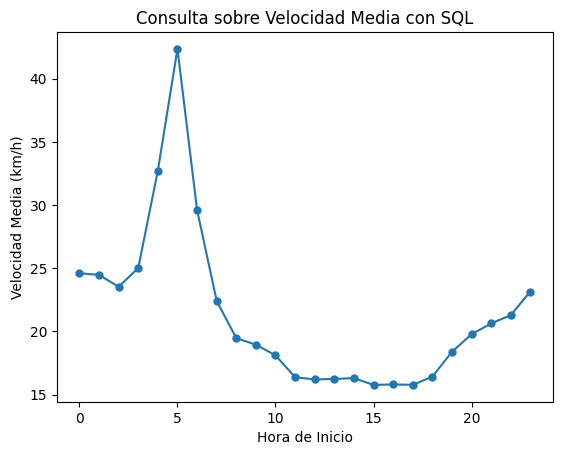

In [10]:
fig, ax = plt.subplots()

x = sql_result.select("hour").rdd.flatMap(lambda x: x).collect()
y = sql_result.select("vel_media_km_h").rdd.flatMap(lambda x: x).collect()

ax.plot(x, y, marker="o", markersize="5")

ax.set_ylabel('Velocidad Media (km/h)')
ax.set_xlabel('Hora de Inicio')
ax.set_title('Consulta sobre Velocidad Media con SQL')

plt.show()

### **3.1.2. Resolución mediante operaciones de dataframes**

Tras la solución mediante `SQL`, se proporciona la siguiente solución empleando operaciones sobre los `dataframes de Spark`. Para ello, se han seguido las siguientes operaciones:

1. Selección de las columnas empleadas en las operaciones: `tpep_dropoff_datetime`, que indica el momento en el que acabó el viaje; `tpep_pickup_datetime`, que indica el momento en el que se inició el viaje; y `trip_distance`, que indica la distancia recorrida.
2. Cálculo de la duración del viaje en segundos añadiendo una nueva columna: `DiffInSeconds`.
3. Cálculo de la velocidad del viaje en *km/h* añadiendo una nueva columna: `vel_km_h`. Adicionalmente, se ha empleado la función `try_divide` para evitar divisiones entre 0.
4. Selección de la hora de inicio del viaje añadiendo una nueva columna: `start_hour`.
5. Selección de las columnas `start_hour` y `vel_km_h` para su posterior agrupación por la columna `start_hour` para el cálculo de las velocidades medias.
6. Ordenación de las filas por la columna `start_hour` en orden ascendente.

Estas operaciones se muestran en el siguiente código:

In [11]:
start_dataframe = time.time()

# Selección de las columnas a usar
df1 = df.select('tpep_dropoff_datetime','tpep_pickup_datetime','trip_distance')

# Cálculo de la velocidad en cada columna
df2 = df1.withColumn('DiffInSeconds', (col('tpep_dropoff_datetime') - col('tpep_pickup_datetime')).cast('long'))
df3 = df2.withColumn('vel_km_h', try_divide('trip_distance','DiffInSeconds')*1.6093*3600)

# Obtención de la hora de inicio
df4 = df3.withColumn('start_hour', hour(col('tpep_pickup_datetime')))

# Agrupación por la hora de inicio y cálculo de las velocidades medias
df5 = df4.select('start_hour', 'vel_km_h').groupBy("start_hour").avg('vel_km_h').sort('start_hour')

# Mostrado de los resultados
df5.show(truncate=False)
end_dataframe = time.time()
print(f'Time taken: {end_dataframe-start_dataframe:.2f} seconds')

+----------+------------------+
|start_hour|avg(vel_km_h)     |
+----------+------------------+
|0         |24.607530287379646|
|1         |24.474041275575924|
|2         |23.534827430691863|
|3         |25.021272750157713|
|4         |32.72397414158072 |
|5         |42.34517060740409 |
|6         |29.605923824870047|
|7         |22.420940585735767|
|8         |19.467807495344772|
|9         |18.957942708637002|
|10        |18.11124430243647 |
|11        |16.38284195350235 |
|12        |16.205058334494385|
|13        |16.2426439188056  |
|14        |16.309638999820866|
|15        |15.771387902240233|
|16        |15.80953000224957 |
|17        |15.778828293991337|
|18        |16.421680358202693|
|19        |18.384367748741326|
+----------+------------------+
only showing top 20 rows
Time taken: 4.93 seconds


Adicionalmente, se ha creado el siguiente código para realizar un histograma que muestre el resultado de la query anterior:

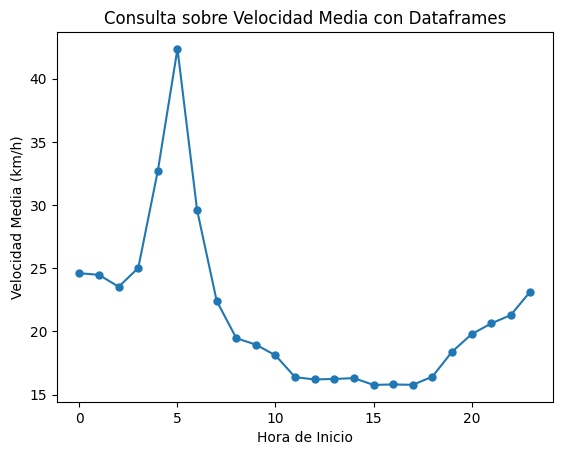

In [12]:
fig, ax = plt.subplots()

x = df5.select("start_hour").rdd.flatMap(lambda x: x).collect()
y = df5.select("avg(vel_km_h)").rdd.flatMap(lambda x: x).collect()

ax.plot(x, y, marker="o", markersize="5")

ax.set_ylabel('Velocidad Media (km/h)')
ax.set_xlabel('Hora de Inicio')
ax.set_title('Consulta sobre Velocidad Media con Dataframes')

plt.show()

### **3.1.3. Resolución mediante RDDs**

Por último, se plantea la reslución del problema empleando `RDDs` y operaciones de mapeo y reducción. Para ello, se sigue el siguiente orden de operaciones:

1. Selección de las columnas empleadas en las operaciones: `tpep_dropoff_datetime`, que indica el momento en el que acabó el viaje; `tpep_pickup_datetime`, que indica el momento en el que se inició el viaje; y `trip_distance`, que indica la distancia recorrida.
2. Ejecución de una función `map` donde la clave es la hora del `datetime` de inicio del viaje y el valor es una tupla. Esta tupla contiene la velocidad media del trayecto y el valor 1, que servirá para calcular una cuenta del número de trayectos en cada hora.
3. Ejecución de una función `reduce` agrupada por cada clave (hora de inicio) que calcula la suma de las velocidades y el cálculo de contador de tryayectos (sumando los segundos valores de las tuplas).
4. Ejecución de una segunda función `map` que se encarga de, para cada clave (hora de inicio), calcular la velocidad media diviendo la suma de las velocidades entre el número de registros en esa clave.
5. Ejecución de una función `take` para mostrar los resultados por pantalla.

Esta concatenación de operaciones se muestran en el siguiente código:

In [13]:
# m1 = df.select('tpep_dropoff_datetime', 'tpep_pickup_datetime', 'trip_distance').rdd.map(lambda x: (hour(x[1]), 5760*x[2]/(x[0]-x[1])))m1 = m1.
start_rdd = time.time()

# Selección de las columnas a usar y primer map
m1 = df.select('tpep_dropoff_datetime', 'tpep_pickup_datetime', 'trip_distance').rdd.map(lambda x: (x[1].hour, (x[2]/(x[0]-x[1]).seconds,1)))

# Reducción, calculo de las sumas de los valores y el conteo
r1 = m1.reduceByKey(lambda x,y: (x[0] + y[0], x[1] + y[1]))

# Segundo map, calculo de medias 
m2 = r1.map(lambda x: (x[0], 1.6093*3600*x[1][0]/x[1][1])).sortBy(lambda x: x[0])
end_tasks = time.time()

# Cálculo de las operaciones y resultados finales
result = m2.take(24)
end_rdd = time.time()
print(result)
print(f'Time taken: {end_tasks-start_rdd:.2f} seconds only creating tasks')
print(f'Time taken: {end_rdd-start_rdd:.2f} seconds with bringing data to python')

[(0, 24.60753339987102), (1, 24.482595331499482), (2, 23.534865804255023), (3, 25.05342801289811), (4, 32.72406864484501), (5, 42.345182353339986), (6, 29.606239251442975), (7, 22.42107002509782), (8, 19.46789315592983), (9, 18.958214792266496), (10, 18.11176788234377), (11, 16.38321325419799), (12, 16.217883695193837), (13, 16.24829008474463), (14, 16.309871606111614), (15, 15.771535810505481), (16, 15.809671708793031), (17, 15.778896485120036), (18, 16.421699822441614), (19, 18.384374466698574), (20, 19.78023796620131), (21, 20.630617536461486), (22, 21.294172439456833), (23, 23.159038936614095)]
Time taken: 44.96 seconds only creating tasks
Time taken: 45.28 seconds with bringing data to python


Adicionalmente, se ha creado el siguiente código para realizar un histograma que muestre el resultado de la query anterior:

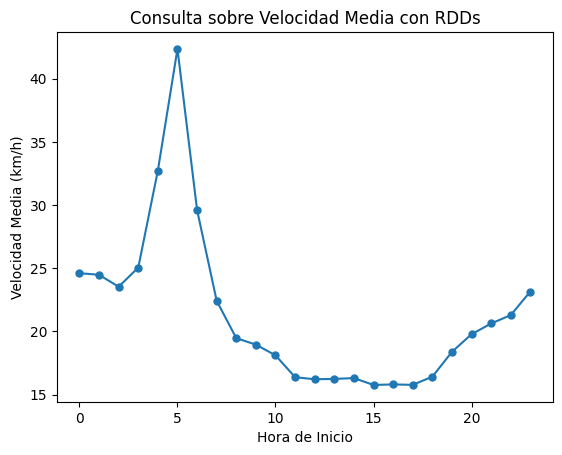

In [14]:
fig, ax = plt.subplots()

x = [value[0] for value in result]
y = [value[1] for value in result]

ax.plot(x, y, marker="o", markersize="5")

ax.set_ylabel('Velocidad Media (km/h)')
ax.set_xlabel('Hora de Inicio')
ax.set_title('Consulta sobre Velocidad Media con RDDs')

plt.show()

## **3.2. Problema 2: Barrios y zonas con más propinas**
<a id="problema-2"></a>

Tal y cómo indica el título de este problema, el objetivo es obtener los barrios y zonas donde los clientes dan más propinas a los conductores. Para resolver este problema, se plantea agrupar los datos por las zonas donde los clientes piden los taxis. Para poder realizar esto, se plantean las siguientes operaciones:

1. Selección de las columnas empleadas en las operaciones: `PULocationID`, que indica el ID de la localización de recogida; `tip_amount`, que indica la propina que el cliente ha dejado al conductor; y `tpep_pickup_datetime`, que indica el momento en el que se inició el viaje.
2. Selección de la hora de inicio del viaje añadiendo una nueva columna: `start_hour`.
3. Agrupación de los valores por las columnas `PULocationID` y `start_hour` para sumar las propinas.
4. Selección de la información adicional de las localizaciones usando un nuevo dataset, renombrando la columna `LocationID` a `PULocationID`.
5. Ejecución de una operación `join` para juntar las localizaciones del primer dataset con la información extendida del segundo dataset usando la columa `PULocationID`.
6. Renombrado de la columna `round(sum(tip_amout))` a `tip_sum` y selección de los parámetros a mostrar en la solución.
7. Ordenado de los resultados por la suma de las propinas en orden descendente.

Estas operaciones se muestran en el siguiente código:

In [15]:
start_dataframe = time.time()

# Selección de las columnas a usar
df_propina = df.select('PULocationID', 'tip_amount', 'tpep_pickup_datetime')

# Obtención de la hora de inicio
df_propina_1 = df_propina.withColumn('start_hour', hour(col('tpep_pickup_datetime')))

# Agrupación para el cálculo de las propinas
df_propina_2 = df_propina_1.groupBy('PULocationID','start_hour').sum('tip_amount')

# Selección de la información extendida de las localizaciones
zone_map_red_1 = zone_map.select('LocationID', 'Borough', 'Zone')
zone_map_red_2 = zone_map_red_1.withColumn('PULocationID', col('LocationID')).select('PULocationID','Borough','Zone')

# Unión de los datos con la información extendida de las localizaciones
df_propina_3 = df_propina_2.join(zone_map_red_2, on='PULocationID').withColumn('tip_sum', round('sum(tip_amount)', 3)).select('start_hour', 'Borough', 'Zone', 'tip_sum')

# Mostrado de los resultados
df_propina_4 = df_propina_3.sort('tip_sum', ascending=False)
df_propina_4.show(n=30)

end_dataframe = time.time()
print(f'Time taken: {end_dataframe-start_dataframe:.2f} seconds')

+----------+---------+-----------------+----------+
|start_hour|  Borough|             Zone|   tip_sum|
+----------+---------+-----------------+----------+
|        16|   Queens|      JFK Airport|2612435.81|
|        17|   Queens|      JFK Airport|2276531.82|
|        15|   Queens|      JFK Airport|2232651.61|
|        19|   Queens|      JFK Airport|2169491.77|
|        20|   Queens|      JFK Airport| 2138776.8|
|        18|   Queens|      JFK Airport|2055028.93|
|        21|   Queens|      JFK Airport|2036117.21|
|        22|   Queens|      JFK Airport| 2008410.0|
|        14|   Queens|      JFK Airport|1922355.26|
|        23|   Queens|      JFK Airport|1799773.15|
|        14|   Queens|LaGuardia Airport|1631676.78|
|        15|   Queens|LaGuardia Airport|1481970.24|
|        13|   Queens|      JFK Airport|1431637.46|
|        16|   Queens|LaGuardia Airport|1426623.74|
|         0|   Queens|      JFK Airport|1271863.81|
|        13|   Queens|LaGuardia Airport|1271754.49|
|        17|

Adicionalmente, se ha creado el siguiente código para realizar un histograma que muestre el resultado de la query anterior:

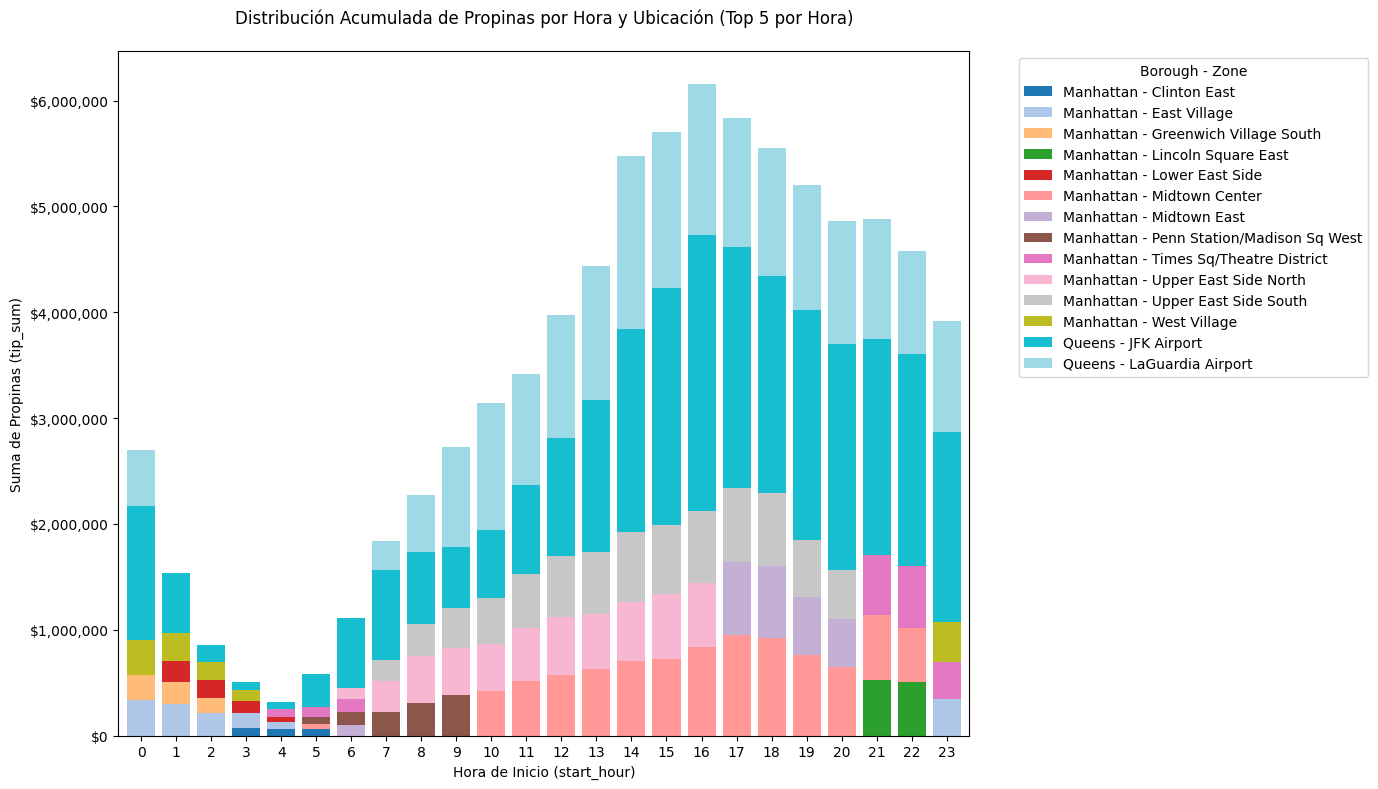

In [16]:
df_pandas = df_propina_4.toPandas()

df_pandas['Borough_Zone'] = df_pandas['Borough'] + ' - ' + df_pandas['Zone']

# Para cada hora, seleccionar solo los top 5 Borough-Zone
top_5_per_hour = []
for hour in df_pandas['start_hour'].unique():
    hour_data = df_pandas[df_pandas['start_hour'] == hour].nlargest(5, 'tip_sum')
    top_5_per_hour.append(hour_data)

# Combinar todos los datos filtrados
df_filtered = pd.concat(top_5_per_hour, ignore_index=True)

# Pivotar los datos para tener start_hour como índice y Borough_Zone como columnas
pivot_df = df_filtered.pivot_table(
    index='start_hour',
    columns='Borough_Zone',
    values='tip_sum',
    aggfunc='sum',
    fill_value=0
)

# Ordenar por start_hour
pivot_df = pivot_df.sort_index()

# Crear el gráfico
fig, ax = plt.subplots(figsize=(14, 8))

# Crear el histograma acumulado (stacked bar chart)
pivot_df.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)

# Personalizar el gráfico
ax.set_xlabel('Hora de Inicio (start_hour)')
ax.set_ylabel('Suma de Propinas (tip_sum)')
ax.set_title('Distribución Acumulada de Propinas por Hora y Ubicación (Top 5 por Hora)', pad=20)

# Rotar las etiquetas del eje X
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Ajustar la leyenda
ax.legend(title='Borough - Zone', 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left',
          fontsize=10)

# Formato de números en el eje Y
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Ajustar el layout para que la leyenda no se corte
plt.tight_layout()

# Mostrar el gráfico
plt.show()

## **3.3. Problema 3: Tipo de pago por rango de precio**
<a id="problema-3"></a>

El objetivo de este problema es mostrar el tipo de pago y el número de pasajeros más comunes agrupando los viajes en rangos del precio total de cada trayecto. Para ello, primero, hay que discretizar la columna `total_amount` en distintos rangos y asignarle un rango a cada trayecto. Esto se realiza mediante una clase de `pyspark` llamada `QuantileDiscretizer` siguiendo los siguientes pasos:

1. Selección de las columnas empleadas en las operaciones: `payment_type`, que indica el tipo de pago realizado; `total_amount`, que indica el precio final del trayecto; y `passenger_count`, que indica el número de pasajeros en el viaje.
2. Filtrado de los valores con un precio final menor a 0 € y aquellos donde no se indica el número de pasajeros.
3. Creación de un objeto de la clase `QuantileDiscretizer` que discretiza la columna `total_amount` en una nueva columna `total_amount_bucket` en agrupando en N buckets.

Tras realizar la discretización de los datos, se realiza una transformación adicional. `QuantileDiscretizer` devuelve un entero que indica el rango al que pertenece el precio, pero no indica el rango per se. Para solucionar este problema que dificulta la interpretación de los resultados, se calcula la amplitud de cada rango y se usa una función auxiliar para transformar los valores de esta columna en rangos. Para entender este problema, se aporta la siguiente tabla de ejemplo asumiendo una discretización en rangos de 10 en 10 €:

| Valor inicial | Valor tras el uso del `QuantileDiscretizer` | Valor tras la segunda transformación |
| ------------- | ------------------------------------------- | ------------------------------------ |
| 5.12€         | 1                                           | 0.0-10.0                             |
| 18.99€        | 2                                           | 10.0-20.0                            |
| 23.45€        | 3                                           | 20.0-30.0                            |
| 0.87€         | 1                                           | 0.0-10.0                             |

Tras explicar estas tranformaciones, se realizan las siguientes operaciones finales:

1. Agrupación de las filas por la columna `total_amount_bucket` para calcular las modas de las columnas `payment_type` y `passenger_count` agrupadas por los rangos de los precios.
2. Realización de la segunda transformación de la columna `total_amount_bucket`, aprovechando para su renombrado como `price_ranges`.
3. Ordenado de los resultados por el rango de precios de manera ascendente.
4. Selección de las columnas finales para mostrar el resultado.

Todo esto se ve en el siguiente código:

In [17]:
from pyspark.ml.feature import QuantileDiscretizer
from pyspark.sql.types import *

# Número de rangos en los que dividir el precio
NUMBER_BUCKETS = 43000

# Función auxiliar que sirve para cambiar los buckets (números enteros) a rangos
def bucket_to_range(valor):
    min_val = np.round((valor-1)*factor_bucket)
    max_val = np.round(min_val + factor_bucket)
    return (f"{min_val}-{max_val}")

# Creación de un UDF para cambiar los buckets a rangos y mejorar la legibilidad del resultado
range_udf = udf(bucket_to_range, StringType())

start_dataframe = time.time()

# Selección de las columnas y filtrado
df_pt1 = df.select('payment_type', 'total_amount', 'passenger_count')
df_pt2 = df_pt1.filter(df_pt1.total_amount > 0).filter(col('passenger_count').isNotNull())

# Discretización de los precios
qds1 = QuantileDiscretizer(inputCol="total_amount", outputCol="total_amount_bucket", numBuckets=NUMBER_BUCKETS)
df_pt2 = qds1.fit(df_pt2).transform(df_pt2)

# Obtención del pago mínimo y máximo para calcular la amplitud de los rangos
max_payment, min_payment = df_pt2.select(max(df_pt2.total_amount), min(df_pt2.total_amount)).toPandas().T.to_dict('list')[0]
factor_bucket = (max_payment - min_payment) / NUMBER_BUCKETS 

# Operaciones finales
df_pt3 = df_pt2.groupBy('total_amount_bucket').agg(mode('payment_type'), mode('passenger_count'))
df_pt4 = df_pt3.withColumn('price_ranges', range_udf(df_pt3['total_amount_bucket'])).sort('total_amount_bucket')

# Mostrado de los resultados
df_pt5 = df_pt4.select('price_ranges', 'mode(passenger_count)', 'mode(payment_type)')
df_pt5.show(n=30)

end_dataframe = time.time()
print(f'Time taken: {end_dataframe-start_dataframe:.2f} seconds')

25/10/26 12:55:36 WARN QuantileDiscretizer: Some quantiles were identical. Bucketing to 2509 buckets as a result.


+------------+---------------------+------------------+
|price_ranges|mode(passenger_count)|mode(payment_type)|
+------------+---------------------+------------------+
|    0.0-20.0|                    1|                 2|
|   20.0-40.0|                    1|                 2|
|   40.0-60.0|                    1|                 2|
|   60.0-80.0|                    1|                 2|
|  80.0-100.0|                    1|                 2|
| 100.0-120.0|                    1|                 2|
| 120.0-140.0|                    1|                 1|
| 141.0-161.0|                    1|                 1|
| 161.0-181.0|                    1|                 1|
| 181.0-201.0|                    1|                 2|
| 201.0-221.0|                    1|                 2|
| 221.0-241.0|                    1|                 2|
| 241.0-261.0|                    1|                 2|
| 261.0-281.0|                    1|                 1|
| 281.0-301.0|                    1|            

Adicionalmente, se ha creado el siguiente código para realizar un histograma que muestre el resultado de la query anterior. Para mostrar unos resultados legibles, se ha limitado a la muestra de los primeros 75 rangos.

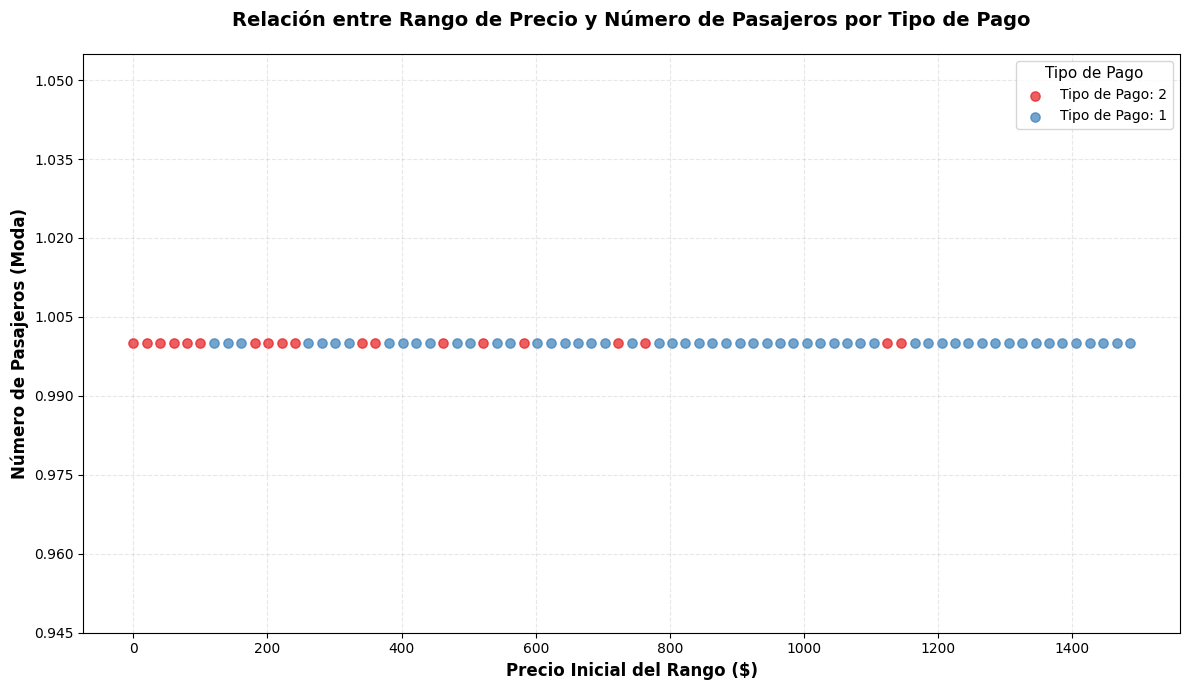

In [18]:
df_pandas = df_pt5.limit(75).toPandas()

# Extraer el primer valor del rango de precios
df_pandas['price_start'] = df_pandas['price_ranges'].str.split('-').str[0].astype(float)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(12, 7))

# Obtener los tipos de pago únicos y asignar colores
payment_types = df_pandas['mode(payment_type)'].unique()
colors = plt.cm.Set1(range(len(payment_types)))
color_map = {pt: colors[i] for i, pt in enumerate(payment_types)}

# Crear el scatter plot agrupado por tipo de pago
for payment_type in payment_types:
    mask = df_pandas['mode(payment_type)'] == payment_type
    ax.scatter(
        df_pandas[mask]['price_start'],
        df_pandas[mask]['mode(passenger_count)'],
        c=[color_map[payment_type]],
        label=f'Tipo de Pago: {payment_type}',
        s=45,
        alpha=0.7
    )

# Personalizar el gráfico
ax.set_xlabel('Precio Inicial del Rango ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Pasajeros (Moda)', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Rango de Precio y Número de Pasajeros por Tipo de Pago', 
             fontsize=14, fontweight='bold', pad=20)

# Configurar la leyenda
ax.legend(title='Tipo de Pago', fontsize=10, title_fontsize=11, loc='best')

# Añadir grid para mejor legibilidad
ax.grid(True, alpha=0.3, linestyle='--')

# Asegurar que el eje Y muestre solo valores enteros
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Ajustar el layout
plt.tight_layout()

# Mostrar el gráfico
plt.show()


# **4. Análisis**
<a id="analisis"></a>

En este apartado se realiza el análisis temporal para los tres métodos implementados para el problema 1. Para poder realizar un análisis del tiempo consumido por cada método, primero, se ha decidido agrupar el código a medir en distintas funciones. Adicionalmente, se realizan pruebas con distinto número de cores para poder ver la diferencia en el speedup de cada método.

## **4.1. Funciones**

Este apartado guarda las funciones que se van a usar en las mediciones.

### **4.1.1. Creación de Spark y lectura de los datos**

In [19]:
def createSparkSession(core_numer: int):
    try:
        spark_speedup.stop()
    except:
        pass
    try:
        spark.stop()
    except:
        pass

    # Re-import functions to avoid namespace conflicts
    from pyspark.sql.functions import col, hour, try_divide

    # Creación de la sesión de spark
    spark = SparkSession.builder.master(f'local[{core_numer}]').getOrCreate()
    sc = spark.sparkContext

    # Read the file
    df = spark.read.format("parquet") \
        .option("inferSchema", "true")  \
        .option("timestampFormat","yyyy-MM-dd HH:mm:ss") \
        .option("header", "true") \
        .option("mode", "DROPMALFORMED") \
        .option("pathGlobFilter", "*.parquet") \
        .load("content/")

    # Eliminado de viajes sin distancia
    df = df.filter(df.trip_distance != 0)

    # Eliminado de viajes instantáneos
    df = df.filter(df.tpep_pickup_datetime != df.tpep_dropoff_datetime)

    # TODO: hacer más filtros
    return spark, sc, df

### **4.1.2. Implementación del problema 1 mediante SQL**

In [20]:
def sqlProcess(sparkContext, df) -> None:
    TABLE_NAME = 'taxi_routes'

    # Query a usar
    SQL = f"""SELECT HOUR(tpep_pickup_datetime) AS hour,
                AVG(trip_distance / DATE_DIFF(SECOND,tpep_pickup_datetime,tpep_dropoff_datetime))*1.6093*3600 as vel_media_km_h 
                FROM {TABLE_NAME} 
                GROUP BY hour 
                SORT BY hour """

    # Creación de una vista sobre la tabla y ejecución de la query
    df.createOrReplaceTempView(TABLE_NAME)
    sql_result = sparkContext.sql(SQL)

    # Mostrado de los resultados
    sql_result.show(24)

### **4.1.3. Implementación del problema 2 mediante Dataframes**

In [21]:
def dataframeProcess(sparkContext, df) -> None:

    # FILTRADO
    df = df.filter(df.trip_distance != 0)
    df = df.filter(df.tpep_pickup_datetime != df.tpep_dropoff_datetime)

    # PROCESADO
    df1_ = df.select('tpep_dropoff_datetime','tpep_pickup_datetime','trip_distance')
    df2_ = df1_.withColumn('DiffInSeconds', (col('tpep_dropoff_datetime') - col('tpep_pickup_datetime')).cast('long'))
    df3_ = df2_.withColumn('vel_km_h', try_divide('trip_distance','DiffInSeconds')*1.6093*3600)
    df4_ = df3_.withColumn('start_hour', hour(col('tpep_pickup_datetime')))
    df5_ = df4_.select('start_hour', 'vel_km_h').groupBy("start_hour").avg('vel_km_h').sort('start_hour')

    df5_.show(truncate=False)

### **4.1.4. Implementación del problema 1 mediante RDDs**

In [22]:
def rddProcess(sparkContext, df) -> None:
    # m1 = df.select('tpep_dropoff_datetime', 'tpep_pickup_datetime', 'trip_distance').rdd.map(lambda x: (hour(x[1]), 5760*x[2]/(x[0]-x[1])))m1 = m1.

    # Selección de las columnas a usar y primer map
    m1 = df.select('tpep_dropoff_datetime', 'tpep_pickup_datetime', 'trip_distance').rdd.map(lambda x: (x[1].hour, (x[2]/(x[0]-x[1]).seconds,1)))

    # Reducción, calculo de las sumas de los valores y el conteo
    r1 = m1.reduceByKey(lambda x,y: (x[0] + y[0], x[1] + y[1]))

    # Segundo map, calculo de medias 
    m2 = r1.map(lambda x: (x[0], 1.6093*3600*x[1][0]/x[1][1])).sortBy(lambda x: x[0])
    end_tasks = time.time()

    # Cálculo de las operaciones y resultados finales
    result = m2.take(24)

## **4.2. Obtención de medidas**

Tras esto, se procede la obtención de las medidas temporales para cada método. Para ello, se realizan tres bucles que iteran por las distintas cantidades de cores que se usará la sesión de Spark. De forma resumida, cada bucle:

1. Pasa el recolector de basura de Python
2. Consigue el tiempo de inicio
3. Crea la sesión de Spark y lee los datos
4. Llama a la función de procesado adecuada
5. Consigue el tiempo de final y calcula la duración del método
6. Guarda la duración del método para el número de cores en el fichero adecuado

Esto se realiza en el siguiente código:

In [23]:
from pyspark.sql.functions import col, hour, try_divide

CORES = [1,2,4,6,8,10,12,14,16]
RESULTS_SQL, RESULTS_DATAFRAME, RESULTS_RDD = {}, {}, {}

activities = (("SQL Result", sqlProcess, RESULTS_SQL),
              ("Dataframe Result", dataframeProcess, RESULTS_DATAFRAME),
              ("RDD Result", rddProcess, RESULTS_RDD))

try:
    spark.stop()
except:
    pass

for activity in activities:
    name, func, results = activity
    for core_number in CORES:
        gc.collect()
        start = time.time()
        spark_speedup, _, df_speedup = createSparkSession(core_number)

        # process
        func(spark_speedup, df_speedup)

        # Register end time
        end = time.time()
        time_taken = end - start
        results[core_number] = time_taken

        with open(f"results/{name.lower().replace(' ', '_')}.json", 'w') as f:
            json.dump(results, f, indent=2)

    spark.stop()

+----+------------------+
|hour|    vel_media_km_h|
+----+------------------+
|   0| 42.46731447638178|
|   1|36.324303480118026|
|   2| 33.57077458866846|
|   3|56.405636927437335|
|   4| 95.10578820702847|
|   5|221.76304321848826|
|   6|113.28308561927575|
|   7| 83.54840348635192|
|   8| 51.24359279919555|
|   9| 32.65028281183002|
|  10| 29.35889879694092|
|  11| 26.85416958001444|
|  12|24.747423636201177|
|  13| 24.75962263965515|
|  14| 29.01603018392828|
|  15|27.390469647279858|
|  16|23.993763506419988|
|  17|  32.2874065449699|
|  18|30.046213114011508|
|  19|28.499344975698566|
|  20|32.977499781112215|
|  21| 34.03871641389966|
|  22| 29.63239310869145|
|  23|30.771513283408698|
+----+------------------+



+----+------------------+
|hour|    vel_media_km_h|
+----+------------------+
|   0| 42.46731447638178|
|   1|36.324303480118026|
|   2| 33.57077458866846|
|   3|56.405636927437335|
|   4| 95.10578820702847|
|   5|221.76304321848826|
|   6|113.28308561927575|
|   7| 83.54840348635192|
|   8| 51.24359279919555|
|   9| 32.65028281183002|
|  10| 29.35889879694092|
|  11| 26.85416958001444|
|  12|24.747423636201177|
|  13| 24.75962263965515|
|  14| 29.01603018392828|
|  15|27.390469647279858|
|  16|23.993763506419988|
|  17|  32.2874065449699|
|  18|30.046213114011508|
|  19|28.499344975698566|
|  20|32.977499781112215|
|  21| 34.03871641389966|
|  22| 29.63239310869145|
|  23|30.771513283408698|
+----+------------------+



+----+------------------+
|hour|    vel_media_km_h|
+----+------------------+
|   0| 42.46731447638178|
|   1|36.324303480118026|
|   2| 33.57077458866846|
|   3|56.405636927437335|
|   4| 95.10578820702847|
|   5|221.76304321848826|
|   6|113.28308561927575|
|   7| 83.54840348635192|
|   8| 51.24359279919555|
|   9| 32.65028281183002|
|  10| 29.35889879694092|
|  11| 26.85416958001444|
|  12|24.747423636201177|
|  13| 24.75962263965515|
|  14| 29.01603018392828|
|  15|27.390469647279858|
|  16|23.993763506419988|
|  17|  32.2874065449699|
|  18|30.046213114011508|
|  19|28.499344975698566|
|  20|32.977499781112215|
|  21| 34.03871641389966|
|  22| 29.63239310869145|
|  23|30.771513283408698|
+----+------------------+



+----+------------------+
|hour|    vel_media_km_h|
+----+------------------+
|   0| 42.46731447638178|
|   1|36.324303480118026|
|   2| 33.57077458866846|
|   3|56.405636927437335|
|   4| 95.10578820702847|
|   5|221.76304321848826|
|   6|113.28308561927575|
|   7| 83.54840348635192|
|   8| 51.24359279919555|
|   9| 32.65028281183002|
|  10| 29.35889879694092|
|  11| 26.85416958001444|
|  12|24.747423636201177|
|  13| 24.75962263965515|
|  14| 29.01603018392828|
|  15|27.390469647279858|
|  16|23.993763506419988|
|  17|  32.2874065449699|
|  18|30.046213114011508|
|  19|28.499344975698566|
|  20|32.977499781112215|
|  21| 34.03871641389966|
|  22| 29.63239310869145|
|  23|30.771513283408698|
+----+------------------+



+----+------------------+
|hour|    vel_media_km_h|
+----+------------------+
|   0| 42.46731447638178|
|   1|36.324303480118026|
|   2| 33.57077458866846|
|   3|56.405636927437335|
|   4| 95.10578820702847|
|   5|221.76304321848826|
|   6|113.28308561927575|
|   7| 83.54840348635192|
|   8| 51.24359279919555|
|   9| 32.65028281183002|
|  10| 29.35889879694092|
|  11| 26.85416958001444|
|  12|24.747423636201177|
|  13| 24.75962263965515|
|  14| 29.01603018392828|
|  15|27.390469647279858|
|  16|23.993763506419988|
|  17|  32.2874065449699|
|  18|30.046213114011508|
|  19|28.499344975698566|
|  20|32.977499781112215|
|  21| 34.03871641389966|
|  22| 29.63239310869145|
|  23|30.771513283408698|
+----+------------------+



...

+----------+------------------+
|start_hour|avg(vel_km_h)     |
+----------+------------------+
|0         |42.467314476381176|
|1         |36.35239479061322 |
|2         |33.63711939808229 |
|3         |56.405636927437726|
|4         |95.1057882070286  |
|5         |221.76304321848815|
|6         |113.28308561927577|
|7         |83.54840348635096 |
|8         |51.24359279919457 |
|9         |32.65028281182945 |
|10        |29.358898796940476|
|11        |26.85416958001393 |
|12        |24.74742363620054 |
|13        |24.759622639654335|
|14        |29.016030183926905|
|15        |27.390469647278632|
|16        |23.993763506419196|
|17        |32.28740654496868 |
|18        |30.046213114009955|
|19        |28.49934497569679 |
+----------+------------------+
only showing top 20 rows


+----------+------------------+
|start_hour|avg(vel_km_h)     |
+----------+------------------+
|0         |42.467314476381176|
|1         |36.35239479061322 |
|2         |33.63711939808229 |
|3         |56.405636927437726|
|4         |95.1057882070286  |
|5         |221.76304321848815|
|6         |113.28308561927577|
|7         |83.54840348635096 |
|8         |51.24359279919457 |
|9         |32.65028281182945 |
|10        |29.358898796940476|
|11        |26.85416958001393 |
|12        |24.74742363620054 |
|13        |24.759622639654335|
|14        |29.016030183926905|
|15        |27.390469647278632|
|16        |23.993763506419196|
|17        |32.28740654496868 |
|18        |30.046213114009955|
|19        |28.49934497569679 |
+----------+------------------+
only showing top 20 rows


+----------+------------------+
|start_hour|avg(vel_km_h)     |
+----------+------------------+
|0         |42.467314476381944|
|1         |36.352394790613005|
|2         |33.637119398082156|
|3         |56.40563692743752 |
|4         |95.10578820702868 |
|5         |221.76304321848852|
|6         |113.28308561927645|
|7         |83.54840348635199 |
|8         |51.243592799195255|
|9         |32.65028281183002 |
|10        |29.35889879694104 |
|11        |26.85416958001446 |
|12        |24.747423636201162|
|13        |24.759622639655024|
|14        |29.0160301839276  |
|15        |27.390469647279257|
|16        |23.993763506419825|
|17        |32.28740654496927 |
|18        |30.046213114010705|
|19        |28.499344975697905|
+----------+------------------+
only showing top 20 rows


+----------+------------------+
|start_hour|avg(vel_km_h)     |
+----------+------------------+
|0         |42.46731447638187 |
|1         |36.35239479061295 |
|2         |33.6371193980821  |
|3         |56.40563692743752 |
|4         |95.10578820702865 |
|5         |221.7630432184884 |
|6         |113.28308561927668|
|7         |83.54840348635223 |
|8         |51.24359279919544 |
|9         |32.650282811830216|
|10        |29.35889879694119 |
|11        |26.854169580014702|
|12        |24.74742363620134 |
|13        |24.759622639655174|
|14        |29.016030183927807|
|15        |27.39046964727943 |
|16        |23.993763506420052|
|17        |32.28740654496949 |
|18        |30.046213114010953|
|19        |28.49934497569821 |
+----------+------------------+
only showing top 20 rows


+----------+------------------+
|start_hour|avg(vel_km_h)     |
+----------+------------------+
|0         |42.46731447638187 |
|1         |36.35239479061295 |
|2         |33.6371193980821  |
|3         |56.40563692743752 |
|4         |95.10578820702865 |
|5         |221.7630432184884 |
|6         |113.28308561927668|
|7         |83.54840348635223 |
|8         |51.24359279919544 |
|9         |32.650282811830216|
|10        |29.35889879694119 |
|11        |26.854169580014702|
|12        |24.74742363620134 |
|13        |24.759622639655174|
|14        |29.016030183927807|
|15        |27.39046964727943 |
|16        |23.993763506420052|
|17        |32.28740654496949 |
|18        |30.046213114010953|
|19        |28.49934497569821 |
+----------+------------------+
only showing top 20 rows


Tras obtener las medidas, usamos el siguiente código para representar los resultados obtenidos:

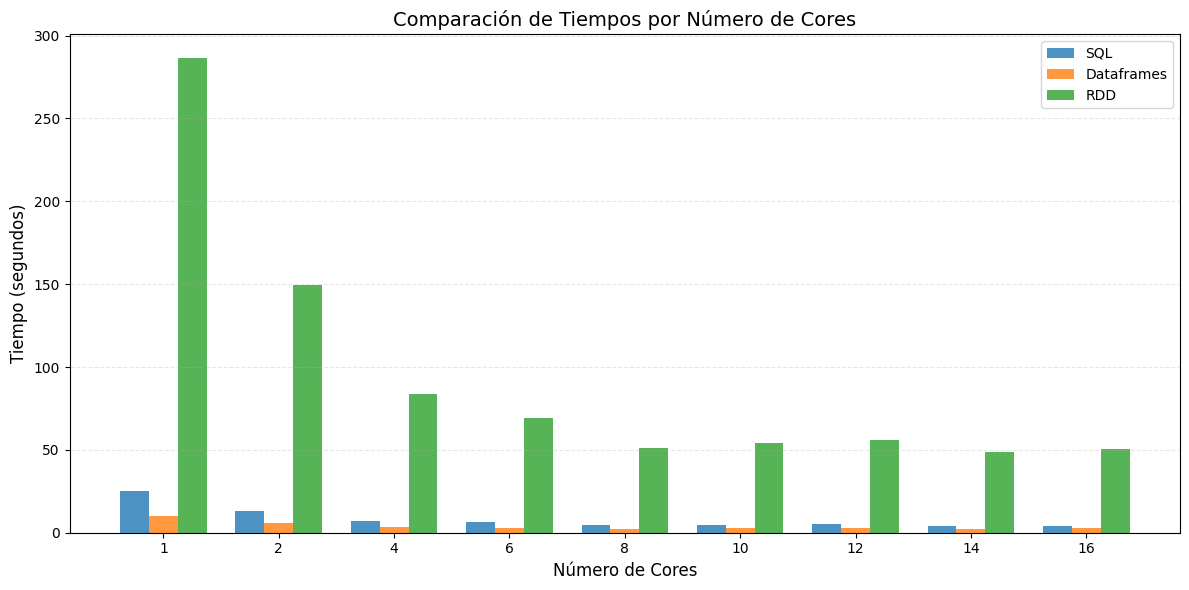

In [25]:


# Cargar los tres archivos JSON
with open('results/sql_result.json', 'r') as f:
    sql_data = json.load(f)

with open('results/dataframe_result.json', 'r') as f:
    df_data = json.load(f)

with open('results/rdd_result.json', 'r') as f:
    rdd_data = json.load(f)

# Convertir las claves a números y ordenar
cores = sorted([int(k) for k in sql_data.keys()])

# Extraer valores en el mismo orden para cada dataset
sql_values = [sql_data[str(c)] for c in cores]
df_values = [df_data[str(c)] for c in cores]
rdd_values = [rdd_data[str(c)] for c in cores]

# Crear el gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Ancho de las barras
ancho = 0.25
x = np.arange(len(cores))
# Crear barras para cada dataset
sql_bars = ax.bar(x - ancho, sql_values, ancho, label='SQL', alpha=0.8)
df_bars = ax.bar(x, df_values, ancho, label='Dataframes', alpha=0.8)
rdd_bars = ax.bar(x + ancho, rdd_values, ancho, label='RDD', alpha=0.8)
# Personalizar el gráfico
ax.set_xlabel('Número de Cores', fontsize=12)
ax.set_ylabel('Tiempo (segundos)', fontsize=12)
ax.set_title('Comparación de Tiempos por Número de Cores', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(cores)
ax.legend()
ax.grid(axis='y', alpha=0.3, linestyle='--')
# Ajustar el layout
plt.tight_layout()
plt.show()

## **4.3. Comparación y speedup**

# **5. Conclusiones**
<a id="conclusiones"></a>
